## Vision Model Alignment Search
In this notebook, we will walk through how to apply MAS to simplistic vision models trained on cifar10.

## Overview

### 1. Define models

In this tutorial, we will assume that the models are already trained. We can use any pytorch based model architecture. 

### 2. Define input data (and train classification head)

We need a dataset for each model. In this tutorial, we will use the same dataset for both models. In principle, however, these datasets can be different. We will also be using cifar10 as our dataset. In this notebook, we will also train the classification head on the loaded data. In principle, this step is unnecessary for pretrained models. 

### 3. Collect model intermediates and outputs

Once we have trained models, we will need to collect model responses for each data point in our dataset. This will give us tuples of inputs, intermediate representations, and outputs for each model that can be used to train the MAS transformation matrices.

### 4. Train the MAS alignment (i.e. rotation matrices)

Using our data tuples, we can systematically select source and target models, patch from the source into the target intermediate representations using an interchange intervention, and then use the output distribution of the source model as the training objective for the transformation matrices. We train until convergence.

### 5. Evaluate the alignment

Finally, we will evaluate the alignment on the cifar 10 test set.

# 1. Define the Models

In [1]:
%load_ext autoreload
%autoreload 2

In [8]:
from vis_training import get_model_and_processor

overwrite = True

models = []
processors = []

#model_names = [
#    "microsoft/resnet-18",
#    "microsoft/resnet-18",
#]
model_names = [
    "microsoft/resnet-18",
    "google/vit-base-patch16-224",
    #"google/vit-base-patch16-224",
]
for model_name in model_names:
    # Models are defined as the backbone (frozen parameters, no head)
    # with an untrained head (unfrozen parameters) that will be trained
    # on the cifar10 dataset before training the MAS alignment
    model, proc = get_model_and_processor(model_name)
    models.append(model.cpu())
    processors.append(proc)


ValueError: Unrecognized model in Kalray/vgg-19. Should have a `model_type` key in its config.json, or contain one of the following strings in its name: aimv2, aimv2_vision_model, albert, align, altclip, apertus, arcee, aria, aria_text, audio-spectrogram-transformer, autoformer, aya_vision, bamba, bark, bart, beit, bert, bert-generation, big_bird, bigbird_pegasus, biogpt, bit, bitnet, blenderbot, blenderbot-small, blip, blip-2, blip_2_qformer, bloom, bridgetower, bros, camembert, canine, chameleon, chinese_clip, chinese_clip_vision_model, clap, clip, clip_text_model, clip_vision_model, clipseg, clvp, code_llama, codegen, cohere, cohere2, cohere2_vision, colpali, colqwen2, conditional_detr, convbert, convnext, convnextv2, cpmant, csm, ctrl, cvt, d_fine, dab-detr, dac, data2vec-audio, data2vec-text, data2vec-vision, dbrx, deberta, deberta-v2, decision_transformer, deepseek_v2, deepseek_v3, deepseek_vl, deepseek_vl_hybrid, deformable_detr, deit, depth_anything, depth_pro, deta, detr, dia,

# 2. Load the input data (and labels) and finetune

In [ ]:
import torch
from vis_training import train_model, get_dataloaders, get_datasets
from torchvision import datasets
import os

batch_size = 128
val_batch_size = 1000
num_workers = 1
num_epochs = 5
lr = 0.001
model_save_dir = "/data2/grantsrb/vision_mas/models"
data_root = "/data2/grantsrb/torch_datasets"
dataset_name = "fashion-mnist"

train_ds, test_ds = get_datasets(dataset_name, data_root)

train_loaders = []
test_loaders = []
for i, processor in enumerate(processors):
    train_loader, test_loader = get_dataloaders(
        train_dataset=train_ds,
        test_dataset=test_ds,
        processor=processor,
        batch_size=batch_size,
        val_batch_size=val_batch_size,
        num_workers=num_workers,
        data_root=data_root,
    )
    train_loaders.append(train_loader)
    test_loaders.append(test_loader)

Loading fashion-mnist...


 87%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                      | 23.0M/26.4M [06:21<01:34, 36.0kB/s]

In [ ]:
dir(train_ds)

In [22]:
import numpy as np
idxs = np.arange(5)
len(train_ds.data[idxs])
len(train_ds.targets[idxs])

TypeError: only integer scalar arrays can be converted to a scalar index

In [9]:
for i, (model, processor) in enumerate(zip(models, processors)):
    train_loader = train_loaders[i]
    test_loader = test_loaders[i]
    model_name = model_names[i].replace("/", "_")
    model_save_path = f"{model_save_dir}/{model_name}_{dataset_name}_sd_{i}.pt"
    if os.path.exists(model_save_path):
        print(f"Loading model from {model_save_path}")
        model.load_state_dict(torch.load(model_save_path))
    else:
        print(f"Finetuning model {i}")
        try:
            model = train_model(
                model=model,
                train_loader=train_loader,
                test_loader=test_loader,
                hyperparameters={"lr": lr, "num_epochs": num_epochs},
            )
        except KeyboardInterrupt:
            print("Interrupted training, continuing...")
            pass
    
    # From here on, we will not update the model parameters
    for p in model.parameters():
        p.requires_grad = False
    
    torch.save(model.state_dict(), model_save_path)


Finetuning model 0
Epoch 0, Batch 0, Loss: 3.0153627395629883, Acc: 0.0625
Epoch 0, Batch 100, Loss: 0.5366522073745728, Acc: 0.8828125
Epoch 0, Batch 200, Loss: 0.34541866183280945, Acc: 0.9296875
Epoch 0, Batch 300, Loss: 0.3610914647579193, Acc: 0.9140625
Epoch 0, Batch 400, Loss: 0.1765606552362442, Acc: 0.9765625
Validating...


0it [00:01, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 2.26 GiB. GPU 0 has a total capacity of 44.35 GiB of which 1006.81 MiB is free. Process 2203241 has 25.69 GiB memory in use. Process 2237463 has 13.42 GiB memory in use. Including non-PyTorch memory, this process has 4.22 GiB memory in use. Of the allocated memory 3.77 GiB is allocated by PyTorch, and 96.10 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

# 3. Collect model intermediates and outputs

In [17]:
import torch
from vis_training import get_actvs_data, get_dataloader

layer_names = [ # need a layer name for each model
    "backbone.encoder.stages.1.layers.0",
    "backbone.encoder.stages.1.layers.0",
]

In [18]:
actvs_train_sets = []
actvs_valid_sets = []

device = 0 if torch.cuda.is_available() else "cpu"
z = zip(models, processors, layer_names)
for i, (model, processor, layer_name) in enumerate(z):
    print(f"Collecting actvs for model {i}")
    model.eval()
    model.to(device)
    train_loader = get_dataloader(
        dataset=train_ds,
        processor=processor,
        batch_size=1000,
        num_workers=num_workers,
        shuffle=False,
    )
    model.cpu()
    
    train_save_path = f"{model_save_dir}/actvs_train_set_{i}.pt"
    valid_save_path = f"{model_save_dir}/actvs_valid_set_{i}.pt"
    if os.path.exists(train_save_path) and not overwrite:
        print(f"Loading training set from {train_save_path}")
        train_set = torch.load(train_save_path)
        valid_set = torch.load(valid_save_path)
    else:
        # the actvs data is a dict of "inputs" (B,C,H,W), "labels" (B,),
        # "actvs" (B,D,H,W) or (B,D), "logits" (B,C), "preds" (B,).
        # Note that because this is a non-sequential setting, we could make
        # the whole process more efficient by ignoring all processing layers
        # leading up to the layer of interest, but that requires us to know
        # the architecture of the model.
        with torch.no_grad():
            print(f"Collecting training set")
            train_set = get_actvs_data(
                model=model,
                data_loader=train_loader,
                layer_name=layer_name,
                verbose=True,
            )
    
            print(f"Collecting validation set")
            valid_set = get_actvs_data(
                model=model,
                data_loader=test_loader,
                layer_name=layer_name,
                verbose=True,
            )
        torch.save(train_set, train_save_path)
        torch.save(valid_set, valid_save_path)
    actvs_train_sets.append(train_set)
    actvs_valid_sets.append(valid_set)
    model.cpu()


  3%|█████▊                                                                                                                                                                          | 2/60 [00:16<08:08,  8.42s/it]


KeyboardInterrupt: 

In [6]:
torch.save(actvs_train_sets, f"{model_save_dir}/actvs_train_sets.pt")
torch.save(actvs_valid_sets, f"{model_save_dir}/actvs_valid_sets.pt")

In [19]:
actvs_train_sets = torch.load(f"{model_save_dir}/actvs_train_sets.pt")
actvs_valid_sets = torch.load(f"{model_save_dir}/actvs_valid_sets.pt")

# 4. Instantiate the MAS alignment object

In [24]:
og_models = [model for model in models]
og_processors = [processor for processor in processors]
og_layer_names = [layer_name for layer_name in layer_names]
og_actvs_train_sets = [actvs_train_set for actvs_train_set in actvs_train_sets]
og_actvs_valid_sets = [actvs_valid_set for actvs_valid_set in actvs_valid_sets]

In [ ]:
from alignment import MASAlignment
from hooks import hook_vision_model

subspace_size = 128 # number of dimensions used in the patching
mtx_type = "orthogonal"
normalize = False # learns to normalize the activations before the transformation matrix
batch_norm = True
identity_rot = False # uses the identity rotation matrix (only use for debugging)
debug = False

if debug:
    models = [og_models[0] for _ in models]
    processors = [og_processors[0] for _ in processors]
    layer_names = [og_layer_names[0] for _ in layer_names]
    actvs_train_sets = [og_actvs_train_sets[0] for _ in actvs_train_sets]
    actvs_valid_sets = [og_actvs_valid_sets[0] for _ in actvs_valid_sets]
else:
    models = [model for model in og_models]
    processors = [processor for processor in og_processors]
    layer_names = [layer_name for layer_name in og_layer_names]
    actvs_train_sets = [actvs_train_set for actvs_train_set in og_actvs_train_sets]
    actvs_valid_sets = [actvs_valid_set for actvs_valid_set in og_actvs_valid_sets]

# the alignment object contains the transformation matrices for each model
# and the patching masks for each model. It also contains the logic for
# performing an alignment intervention (i.e. transferring causal activity
# from a source model to a target model).
alignment = MASAlignment(
    model_dims=[data["actvs"].shape[1] for data in actvs_train_sets],
    mtx_type=mtx_type,
    subspace_sizes=subspace_size,
    normalize=normalize,
    batch_norm=batch_norm,
    identity_rot=identity_rot,
)

# We need to hook the models in order to perform the patching intervention
# at the desired layer.
try:
    hooks = [hook.remove() for hook in hooks]
except:
    pass

hooks = []
for model,layer in zip(models, layer_names):
    hooks.append(
        hook_vision_model(model, layer, alignment)
    )

Using subspace sizes: [128]


# 5. Train the MAS alignment

In [ ]:
from vis_training import train_mas_alignment_one_epoch, evaluate_mas_alignment
import torch.optim as optim
import numpy as np
import pandas as pd

num_epochs = 25
batch_size = 256
lr = 0.0005
one_hot_loss = False
label_smoothing = 0.0
train_directions = None
ground_truth_labels = False
val_batch_size = 1000

device = 0 if torch.cuda.is_available() else "cpu"
alignment.to(device)
alignment.train()
optimizer = optim.RMSprop(alignment.parameters(), lr=lr)
train_dfs = []
valid_dfs = []
for epoch in range(num_epochs):
    print(f"Epoch {epoch} - Training")
    train_df = train_mas_alignment_one_epoch(
        models=models,
        alignment=alignment,
        actvs_sets=actvs_train_sets,
        batch_size=batch_size,
        optimizer=optimizer,
        one_hot_loss=one_hot_loss,
        label_smoothing=label_smoothing,
        train_directions=train_directions,
        use_ground_truth_labels=ground_truth_labels,
    )
    print(f"Epoch {epoch} - Validating")
    valid_df = evaluate_mas_alignment(
        models=models,
        alignment=alignment,
        actvs_sets=actvs_valid_sets,
        batch_size=val_batch_size,
        one_hot_loss=one_hot_loss,
        use_ground_truth_labels=ground_truth_labels,
    )

    cols = ["actn_loss","cl_loss","acc"]
    groups = ["src_idx","trg_idx"]

    train = train_df.groupby(groups)[cols].mean().reset_index()
    train["epoch"] = epoch
    train_dfs.append(train)

    valid = valid_df.groupby(groups)[cols].mean().reset_index()
    valid["epoch"] = epoch
    valid_dfs.append(valid)
    print()
    print(train.sort_values(by=groups,ascending=True))
    valid.columns = ["valid_"+col if col in cols else col for col in valid.columns]
    print(valid.sort_values(by=groups,ascending=True))
    print(
        "Train IIA:", round(np.min(train["acc"]), 5),
        "|| Loss:", round(np.max(train["actn_loss"]), 5)
    )
    print(
        "Valid IIA:", round(np.min(valid["valid_acc"]), 5),
        "|| Loss:", round(np.max(valid["valid_actn_loss"]), 5)
    )

Epoch 0
Batch 9984/10000 IIA: 0.9375 Loss: 0.6057357788085938                                                               
   src_idx  trg_idx  actn_loss  cl_loss       acc  epoch
0        0        0   0.566333      0.0  0.999841      0
1        0        1   0.688486      0.0  0.874251      0
2        1        0   0.689693      0.0  0.872684      0
3        1        1   0.566333      0.0  0.999920      0
   src_idx  trg_idx  valid_actn_loss  valid_cl_loss  valid_acc  epoch
0        0        0         0.572126            0.0   1.000000      0
1        0        1         0.694260            0.0   0.873145      0
2        1        0         0.692942            0.0   0.872363      0
3        1        1         0.572126            0.0   1.000000      0
Train IIA: 0.87268 || Loss: 0.68969
Valid IIA: 0.87236 || Loss: 0.69426
Epoch 1
Batch 9984/10000 IIA: 0.9375 Loss: 0.6039549112319946                                                               
   src_idx  trg_idx  actn_loss  cl_loss    

Traceback (most recent call last):
  File "/home/grantsrb/anaconda3/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1944293/1403313382.py", line 22, in <module>
    train_df = train_mas_alignment_one_epoch(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/grantsrb/src/mas/vision/vis_utils.py", line 376, in train_mas_alignment_one_epoch
  File "/home/grantsrb/anaconda3/lib/python3.11/site-packages/torch/_tensor.py", line 647, in backward
    torch.autograd.backward(
  File "/home/grantsrb/anaconda3/lib/python3.11/site-packages/torch/autograd/__init__.py", line 354, in backward
    _engine_run_backward(
  File "/home/grantsrb/anaconda3/lib/python3.11/site-packages/torch/autograd/graph.py", line 829, in _engine_run_backward
    return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
           ^^^^^^^^^^^^^^^^^^^^^^^^^

In [32]:
train_df = pd.concat(train_dfs)
valid_df = pd.concat(valid_dfs)

In [33]:
import datetime

def get_timestamp():
    return datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

In [ ]:
train_df.columns = ["train_"+col if col in cols else col for col in train_df.columns]
valid_df.columns = ["valid_"+col if col in cols else col for col in valid_df.columns]
main_df = pd.merge(train_df, valid_df, on=groups+["epoch"])

timestamp = get_timestamp()
m1 = model_names[0].replace("/", "_")
m2 = model_names[1].replace("/", "_")
main_df.to_csv(f"csvs/{m1}_{m2}_mas_results_{timestamp}.csv", index=False, header=True)
main_df.head()

,src_idx,trg_idx,train_actn_loss,train_cl_loss,train_acc,epoch,valid_actn_loss,valid_cl_loss,valid_acc
0,0,0,0.566333,0.0,0.999841,0,0.572126,0.0,1.000000
1,0,1,0.688486,0.0,0.874251,0,0.694260,0.0,0.873145
2,1,0,0.689693,0.0,0.872684,0,0.692942,0.0,0.872363
3,1,1,0.566333,0.0,0.999920,0,0.572126,0.0,1.000000
4,0,0,0.566701,0.0,0.999880,1,0.572126,0.0,1.000000


# 6. Evaluate results

In [ ]:
main_df = pd.read_csv(f"csvs/{m1}_{m2}_mas_results_{timestamp}.csv")

In [ ]:
main_df["direction"] = main_df["src_idx"].astype(str) + "->" + main_df["trg_idx"].astype(str)
all_df = main_df[["direction","epoch"]+cols]
cols = ["train_acc","valid_acc", "train_actn_loss", "valid_actn_loss"]
all_dfs = [all_df]
for agg in ["min","max","mean"]:
    df = all_df.groupby(["epoch"])[cols].agg(agg).reset_index()
    df["epoch"] = df.index
    df["direction"] = agg
    all_dfs.append(df)
all_df = pd.concat(all_dfs, sort=True)
all_df.head()

In [45]:
set(all_df["direction"])

{'0->0', '0->1', '1->0', '1->1', 'max', 'mean', 'min'}

/tmp/ipykernel_1944293/1755418564.py:8: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(
/home/grantsrb/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/grantsrb/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/grantsrb/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = gr

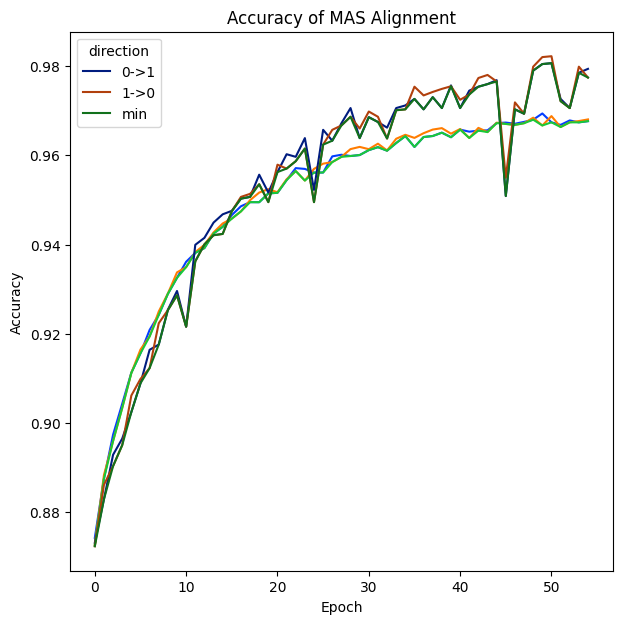

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(7,7))
ax = plt.gca()

plot_df = all_df[all_df["direction"].isin({"min", "1->0", "0->1"})]
sns.lineplot(
    data=plot_df,
    x="epoch",
    y="train_acc",
    hue="direction",
    ax=ax,
    legend=False,
    palette=sns.color_palette("bright"),
)

sns.lineplot(
    data=plot_df,
    x="epoch",
    y="valid_acc",
    hue="direction",
    ax=ax,
    legend=True,
    palette=sns.color_palette("dark"),
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy of MAS Alignment")

plt.show()

/tmp/ipykernel_1944293/2069286042.py:5: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.lineplot(
/home/grantsrb/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/grantsrb/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/grantsrb/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = gr

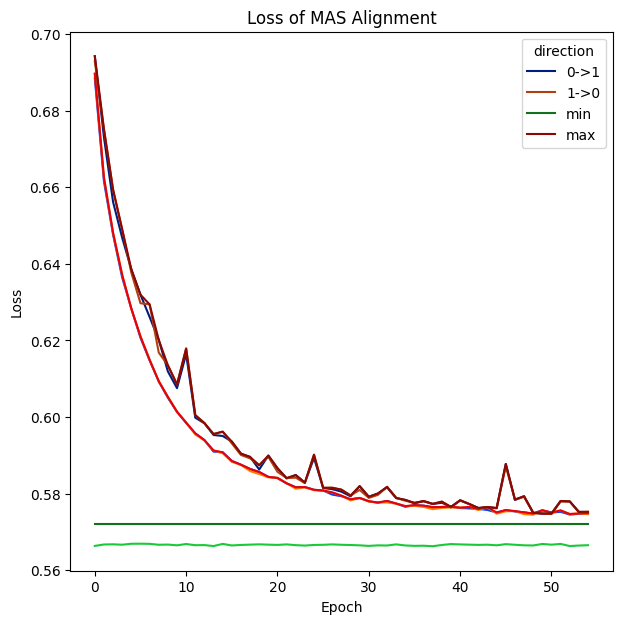

In [54]:
fig = plt.figure(figsize=(7,7))
ax = plt.gca()

plot_df = all_df[all_df["direction"].isin({"max", "min", "1->0", "0->1"})]
sns.lineplot(
    data=plot_df,
    x="epoch",
    y="train_actn_loss",
    hue="direction",
    legend=False,
    ax=ax,
    palette=sns.color_palette("bright"),
)

sns.lineplot(
    data=plot_df,
    x="epoch",
    y="valid_actn_loss",
    hue="direction",
    ax=ax,
    legend=True,
    palette=sns.color_palette("dark"),
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss of MAS Alignment")

plt.show()